Let's explore the maritime world. In this dataset: https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst, you'll be able to visualize all the positions of ships off US coasts for one day: 01/08/2025. You can look this URL up directly in pandas, it can handle the decompression (this is a compressed CSV). This is a large dataset, so your operations may take longer than what we've seen so far. To understand what each column is, here is the data dictionary: https://coast.noaa.gov/data/marinecadastre/ais/data-dictionary.pdf



In [ ]:
URL = "https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst"
import pandas as pd
df = pd.read_csv(URL)
df

,mmsi,base_date_time,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver
0,367793030,2025-01-08 00:00:00,-122.40506,47.68588,4.6,155.5,NaN,WN1622SL,NaN,WDJ5962,37.0,NaN,10.0,3.0,NaN,NaN,B
1,338160209,2025-01-08 00:00:00,-119.69199,34.40719,0.0,106.3,NaN,WESTERLY,NaN,NaN,36.0,NaN,11.0,4.0,NaN,NaN,B
2,266283000,2025-01-08 00:00:01,-74.24126,38.41834,15.5,187.9,190.0,OBERON,IMO9377509,SKJF,70.0,0.0,237.0,32.0,9.1,70.0,A
3,368013620,2025-01-08 00:00:10,-74.04712,40.10181,0.0,252.3,NaN,MARKET PRICE,NaN,WDJ8153,30.0,NaN,17.0,6.0,NaN,NaN,B
4,368144150,2025-01-08 00:00:09,-119.22453,34.16235,0.0,169.6,NaN,SILENT LADY,NaN,WDL5759,37.0,NaN,12.0,5.0,NaN,NaN,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5929626,368920000,2025-01-08 18:58:42,144.66472,13.42224,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A
5929627,368920000,2025-01-08 19:49:42,144.66471,13.42224,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A
5929628,368920000,2025-01-08 21:13:42,144.66474,13.42225,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A
5929629,368920000,2025-01-08 22:07:42,144.66475,13.42225,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A


Please provide a notebook (.ipynb file) posted here and on your Github, in your data-analytics repo (please add a link to the repo in your submission) with the following:
Load the dataframe
Set the index to the base_date_time. Your index should be a DateTimeIndex
Clean the data: we don't want any row where the sog is null


In [ ]:
#Check if the base_date_time field is unique for Index
df['base_date_time'].is_unique
#To drop the null sog values
df = df.dropna(subset=['sog'])
# Check if the base_date_time field have duplicate values before assigning it as an index
df['base_date_time'].is_unique
# Removed dupes, so unique values are present
#df = df.drop_duplicates(subset=['base_date_time'])
#Check again to confirm
df['base_date_time'].is_unique
#Set the index to the base_date_time + convert into datetime
df['base_date_time'] = pd.to_datetime(df['base_date_time'])
df = df.set_index('base_date_time')
df.index




/tmp/ipykernel_26731/660033222.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['base_date_time'] = pd.to_datetime(df['base_date_time'])


DatetimeIndex(['2025-01-08 00:00:00', '2025-01-08 00:00:00',
               '2025-01-08 00:00:01', '2025-01-08 00:00:10',
               '2025-01-08 00:00:09', '2025-01-08 00:00:10',
               '2025-01-08 00:00:19', '2025-01-08 00:00:20',
               '2025-01-08 00:00:05', '2025-01-08 00:00:04',
               ...
               '2025-01-08 23:21:37', '2025-01-08 23:26:18',
               '2025-01-08 23:36:28', '2025-01-08 23:39:28',
               '2025-01-08 18:01:42', '2025-01-08 18:58:42',
               '2025-01-08 19:49:42', '2025-01-08 21:13:42',
               '2025-01-08 22:07:42', '2025-01-08 23:34:42'],
              dtype='datetime64[ns]', name='base_date_time', length=5917091, freq=None)

First Analysis: When are boats out? Display a line graph where your x-axis is the hour of the day, and the y-axis is the number of unique vessels out at that hour. Hint: the MMSI column is a great way to identity a unique vessel. What time (UTC) saw the most boats out on the water? And the least? Does this track with what you could expect?


In [ ]:
import seaborn as sns

<Axes: xlabel='hour', ylabel='mmsi'>

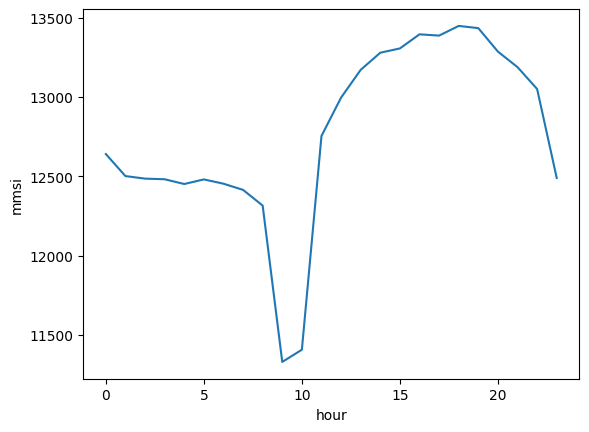

In [ ]:
#Grab the hour from the index
df['hour'] = df.index.hour
#Group the unique MMSI per hour
hourly_boats = df.groupby('hour')['mmsi'].nunique().reset_index()
sns.lineplot(hourly_boats, x='hour', y='mmsi')
#There were most boats out at 18:00 UTC and the least at 9:00 UTC


Second Analysis: let's look at a specific boat, the Henry Hudson (MMSI: 366651000). The owner of the boat has asked us how long the boat engines were active for that day. To get to this, you must:
 a) Figure out when the boat was "accelerating". Create a column called "acceleration", which is going to be the difference between each "sog". Hints: to achieve this, use the "diff()" function on your column. Be sure that your index is sorted, meaning the rows are sorted by time (.sort_index() is very helpful for this)


In [ ]:
#filter only the MMSI 366651000
hudson_df = df[df['mmsi'] == 366651000]
#sort index
hudson_df = hudson_df.sort_index()
#crete a accelaration column with diff() function
hudson_df['acceleration']= hudson_df['sog'].diff()
hudson_df['acceleration']

,acceleration
base_date_time,
2025-01-08 00:00:04,NaN
2025-01-08 00:01:14,5.5
2025-01-08 00:02:45,5.7
2025-01-08 00:03:55,0.4
2025-01-08 00:05:06,0.2
...,...
2025-01-08 23:52:09,11.9
2025-01-08 23:53:38,-8.1
2025-01-08 23:55:19,-4.3


 b) Create a duration column, which is the difference between each "base_date_time"

In [ ]:
#in order to calculate for base_date_time, reset the index
hudson_df = hudson_df.reset_index()
#sort index
hudson_df = hudson_df.sort_index()
#create a new column duration that gets the difference between the base date times
hudson_df['duration']= hudson_df["base_date_time"].diff()
hudson_df['duration']= hudson_df['duration'].dt.total_seconds()/60
hudson_df['duration']

,duration
0,NaN
1,1.166667
2,1.516667
3,1.166667
4,1.183333
...,...
681,1.833333
682,1.483333
683,1.683333
684,1.833333



 c) Once you have a column "acceleration" and "duration", we can assume that the boat engines were active if the "acceleration" is greater than 0. Filter your dataframe to only have rows where the acceleration is positive.


In [ ]:
hudson_df= hudson_df[hudson_df['acceleration']>0]
hudson_df

,base_date_time,mmsi,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver,hour,acceleration,duration
1,2025-01-08 00:01:14,366651000,-74.02209,40.75843,5.5,129.9,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,5.5,1.166667
2,2025-01-08 00:02:45,366651000,-74.01930,40.75736,11.2,114.7,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,5.7,1.516667
3,2025-01-08 00:03:55,366651000,-74.01468,40.75834,11.6,61.5,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,0.4,1.166667
4,2025-01-08 00:05:06,366651000,-74.01090,40.76075,11.8,61.2,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,0.2,1.183333
7,2025-01-08 00:09:06,366651000,-74.00399,40.76080,0.1,347.4,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,0.1,1.183333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677,2025-01-08 23:46:25,366651000,-74.01864,40.75475,14.2,201.8,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,23,0.4,1.100000
680,2025-01-08 23:50:19,366651000,-74.02167,40.75286,0.5,65.1,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,23,0.5,1.100000
681,2025-01-08 23:52:09,366651000,-74.01863,40.75578,12.4,347.9,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,23,11.9,1.833333
684,2025-01-08 23:57:09,366651000,-74.02057,40.75790,10.7,121.9,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,23,10.7,1.833333


d) Sum up the "duration" column to see how long the engines were active for that day. This will allow us to answer the boat captain
Bonus: create a function that takes the MMSI as a parameter, and return the active engine time for that day. Name this function calculate_total_active_engine_time.



In [ ]:
#Sum up the converted durations
hudson_df['duration'].sum()



np.float64(483.4)

In [ ]:
def calculate_total_active_engine_time(mmsi_id,input_df):
  input_df = input_df[input_df['mmsi'] == mmsi_id]
  input_df =input_df.sort_values('base_date_time')
  #crete a accelaration column with diff() function
  input_df['acceleration']= input_df['sog'].diff()
  #create a new column duration that gets the difference between the base date times
  input_df['duration']= input_df["base_date_time"].diff()
  input_df['duration']=input_df['duration'].dt.total_seconds()/60
  input_df['duration'].sum()
  active_df = input_df[input_df['acceleration']>0]

  return active_df['duration'].sum()

calculate_total_active_engine_time(366651000,df)

KeyError: 'base_date_time'